In [ ]:
print("hello world")

hello world


In [ ]:
import torch
import torchvision
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# transforms = what we do to every image before feeding to model
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),        # resize to what MobileNetV3 expects
    transforms.RandomHorizontalFlip(),    # data augmentation - flip randomly
    transforms.RandomRotation(10),        # slight random rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # vary brightness
    transforms.ToTensor(),                # convert image to tensor (numbers)
    transforms.Normalize(                 # normalize to what pretrained model expects
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms defined successfully")

Transforms defined successfully


In [ ]:
import os
from torch.utils.data import random_split

data_dir = "../data"

# ImageFolder reads folder names as labels automatically
# fire/ = class 0, no_fire/ = class 1 (alphabetical)
full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transforms)

print(f"Classes found: {full_dataset.classes}")
print(f"Class mapping: {full_dataset.class_to_idx}")
print(f"Total images:  {len(full_dataset)}")

Classes found: ['fire', 'no_fire']
Class mapping: {'fire': 0, 'no_fire': 1}
Total images:  1140


In [ ]:
total = len(full_dataset)
train_size = int(0.8 * total)   # 80% for training
val_size   = total - train_size  # 20% for validation

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# val set gets different transforms (no augmentation)
val_dataset.dataset.transform = val_transforms

print(f"Training images:   {train_size}")
print(f"Validation images: {val_size}")

Training images:   912
Validation images: 228


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,     # process 32 images at once
    shuffle=True,      # mix images every epoch
    num_workers=2      # parallel loading (use 0 if you get errors on Windows)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches:   29
Validation batches: 8


In [ ]:
# grab one batch and inspect it
images, labels = next(iter(train_loader))

print(f"Batch image shape: {images.shape}")   # should be [32, 3, 224, 224]
print(f"Batch label shape: {labels.shape}")   # should be [32]
print(f"Label values:      {labels}")         # mix of 0s and 1s
print(f"Pixel value range: {images.min():.2f} to {images.max():.2f}")

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Label values:      tensor([1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
        1, 1, 0, 1, 1, 1, 0, 0])
Pixel value range: -2.12 to 2.64


In [ ]:
import torch.nn as nn

# load pretrained MobileNetV3 — already trained on 1.2M images
model = torchvision.models.mobilenet_v3_small(weights="IMAGENET1K_V1")

# freeze all layers — we don't want to change what it already learned
for param in model.parameters():
    param.requires_grad = False

# replace ONLY the last layer for our 2 classes (fire / no fire)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, 2)

# count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} out of {total_params:,}")
print("Model ready!")

Trainable params: 2,050 out of 1,519,906
Model ready!


In [ ]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")   # cpu or cuda

model = model.to(device)

criterion = nn.CrossEntropyLoss()           # loss function for classification
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.00001                                # learning rate
)

Using device: mps


In [10]:
from tqdm import tqdm

EPOCHS = 20
best_val_acc = 0.0

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(EPOCHS):
    # ── training phase ──
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ── validation phase ──
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss    += loss.item()
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = 100. * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d} | "
          f"Train loss: {train_loss:.3f} | Train acc: {train_acc:.1f}% | "
          f"Val loss: {val_loss:.3f} | Val acc: {val_acc:.1f}%")

    # save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "../models/best_model.pth")
        print(f"   ✓ Best model saved ({val_acc:.1f}%)")

print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.1f}%")

Epoch 1/20: 100%|██████████| 29/29 [00:15<00:00,  1.82it/s]


Epoch 01 | Train loss: 0.754 | Train acc: 43.4% | Val loss: 0.818 | Val acc: 29.8%
   ✓ Best model saved (29.8%)


Epoch 2/20: 100%|██████████| 29/29 [00:15<00:00,  1.88it/s]


Epoch 02 | Train loss: 0.738 | Train acc: 46.4% | Val loss: 0.792 | Val acc: 34.2%
   ✓ Best model saved (34.2%)


Epoch 3/20: 100%|██████████| 29/29 [00:13<00:00,  2.12it/s]


KeyboardInterrupt: 

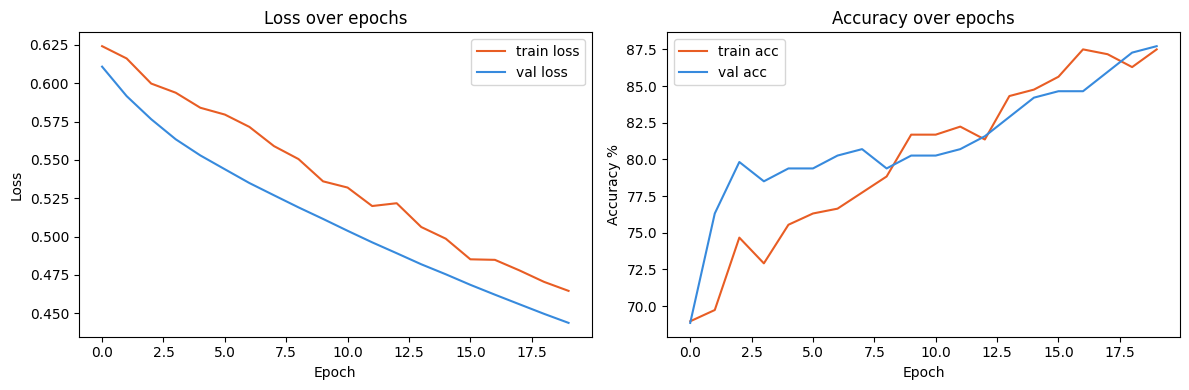

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="train loss", color="#E85D24")
ax1.plot(val_losses,   label="val loss",   color="#378ADD")
ax1.set_title("Loss over epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(train_accs, label="train acc", color="#E85D24")
ax2.plot(val_accs,   label="val acc",  color="#378ADD")
ax2.set_title("Accuracy over epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy %")
ax2.legend()

plt.tight_layout()
plt.show()